# Predictive Modelling - Implementation
Script for applying the built RFC, including:
* Data pre-processing
* Feature enginnering
* Model prediction

In [60]:
# import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import datetime
from datetime import datetime, timedelta, timezone
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from joblib import load

In [61]:
# import raw data
# enrolment + RoA

enrolment_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Predictive modelling/QA_Jun2026/Course - Category - Enrollments.csv'

cert_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Predictive modelling/QA_Jun2026/Course - Certificates.csv'

# date - first enrol

date_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Predictive modelling/QA_Jun2026/Course - First Enrollment.csv'

# workload_lang + num of sections
workload_lang_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/workload_lang.csv'

# Mean Q1 & Q4 --> will be done by Rio
mean_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Predictive modelling/QA_Jun2026/survey_features.csv'


In [62]:
# merge Moodle query
enrol_df = pd.read_csv(enrolment_path)

# subset enrol_df
enrol_df_copy = enrol_df.copy()
enrol_df_copy = enrol_df_copy.loc[enrol_df_copy['visible'] == 1]
enrol_df_copy = enrol_df_copy.drop(['firstEnrollment', 'visible'], axis = 1)

cert_df = pd.read_csv(cert_path)

date_df = pd.read_csv(date_path)

mean_df = pd.read_csv(mean_path)


In [63]:
# clean up cert_df
participation_key = r'teilnahmebestätigung|participation|teilnahmebescheinigung'
achievement_key = r'leistungsnachweis|leistungsnachweise|achivement|record of achievement|zertifikat|certificate|transcript of records'

cert_df['certificateName'] = cert_df['certificateName'].str.lower()

def classify_cert(name):
    if pd.isna(name):
        return None
    name = name.lower()
    if re.search(participation_key, name):
        return 'CoP'
    if re.search(achievement_key, name):
        return 'RoA'
    else:
        return None

cert_df['certType'] = cert_df['certificateName'].apply(classify_cert)

cert_df_filtered = cert_df[cert_df['certType'].notna()]

cert_overview = cert_df_filtered.groupby(['courseID', 'certType'])['amount'].sum().unstack('certType').reset_index()

cert_overview.fillna(0, inplace = True)

cert_overview[['CoP', 'RoA']] = cert_overview[['CoP', 'RoA']].astype(int)

cert_overview.head()


certType,courseID,CoP,RoA
0,2,0,1
1,3,0,1
2,6,155,120
3,7,2,1
4,10,269,251


In [64]:
# survey check
mean_df.head()

,courseID,mean_Q1,mean_Q4
0,6,2.13,2.21
1,10,1.62,1.85
2,19,1.77,1.90
3,27,1.76,2.08
4,28,2.02,2.31


In [65]:
# merge table
print(len(enrol_df))
print(len(cert_overview))
feature_merged = enrol_df_copy.merge(cert_overview, how = 'left', on = 'courseID', validate = '1:1')
print(len(feature_merged))

304
152
201


In [66]:
feature_merged = feature_merged.merge(date_df, how = 'left', on = 'courseID', validate = '1:1')
print(len(feature_merged))
feature_merged.head()

201


,courseID,courseName,categoryName,enrollments,CoP,RoA,firstEnrollment
0,106,Einführung in die KI,Über KI,22038,3519.0,2853.0,2024-09-25 09:33:48+02
1,58,AICE your exams – Generative KI als Copilot im...,Studieren,14215,9766.0,5382.0,2023-11-14 15:30:51+01
2,322,IBM-Grundlagen der Künstlichen Intelligenz,Über KI,10612,2798.0,2825.0,2025-04-02 14:44:52+02
3,99,KI für Alle 1: Einführung in die Künstliche In...,Über KI,9496,801.0,610.0,2023-12-13 12:54:20+01
4,313,EU AI Act Essentials,Studieren,9361,3339.0,2589.0,2025-02-03 08:50:05+01


In [67]:
feature_merged = feature_merged.merge(mean_df, how = 'left', on = 'courseID', validate = '1:1')
print(len(feature_merged))

feature_merged.head()

201


,courseID,courseName,categoryName,enrollments,CoP,RoA,firstEnrollment,mean_Q1,mean_Q4
0,106,Einführung in die KI,Über KI,22038,3519.0,2853.0,2024-09-25 09:33:48+02,1.66,1.98
1,58,AICE your exams – Generative KI als Copilot im...,Studieren,14215,9766.0,5382.0,2023-11-14 15:30:51+01,2.16,2.27
2,322,IBM-Grundlagen der Künstlichen Intelligenz,Über KI,10612,2798.0,2825.0,2025-04-02 14:44:52+02,1.81,2.10
3,99,KI für Alle 1: Einführung in die Künstliche In...,Über KI,9496,801.0,610.0,2023-12-13 12:54:20+01,1.72,2.16
4,313,EU AI Act Essentials,Studieren,9361,3339.0,2589.0,2025-02-03 08:50:05+01,1.58,1.79


In [68]:
# import workload_lang - NA removal
workload_lang = pd.read_csv(workload_lang_path, sep = ';', encoding = 'utf8')
print(len(workload_lang))
#workload_lang[workload_lang.duplicated()]

feature_merged = feature_merged.merge(workload_lang, how = 'left', on = 'courseID', validate = '1:1')

feature_merged = feature_merged.drop(['course', 'workload_hrs', 'CoP'], axis = 1)

print(len(workload_lang))

feature_merged.head()

103
103


,courseID,courseName,categoryName,enrollments,RoA,firstEnrollment,mean_Q1,mean_Q4,lang,num_section
0,106,Einführung in die KI,Über KI,22038,2853.0,2024-09-25 09:33:48+02,1.66,1.98,DE,7.0
1,58,AICE your exams – Generative KI als Copilot im...,Studieren,14215,5382.0,2023-11-14 15:30:51+01,2.16,2.27,DE,7.0
2,322,IBM-Grundlagen der Künstlichen Intelligenz,Über KI,10612,2825.0,2025-04-02 14:44:52+02,1.81,2.10,DE,9.0
3,99,KI für Alle 1: Einführung in die Künstliche In...,Über KI,9496,610.0,2023-12-13 12:54:20+01,1.72,2.16,DE,21.0
4,313,EU AI Act Essentials,Studieren,9361,2589.0,2025-02-03 08:50:05+01,1.58,1.79,DE,6.0


In [69]:
# duration

feature_merged['firstEnrollment'] = pd.to_datetime(feature_merged['firstEnrollment'], utc = True, errors="coerce")

#feature_merged['duration'] = datetime.now(timezone.utc) - feature_merged['firstEnrollment']
# in case with specific dates
reference_date = pd.Timestamp("2026-06-29 12:00:00", tz="UTC")
feature_merged['duration'] = reference_date - feature_merged['firstEnrollment']

feature_merged.info()

feature_merged['duration'] = (feature_merged['duration'].dt.days).astype(str).astype('float')

feature_merged = feature_merged.drop(['firstEnrollment'], axis = 1)

feature_merged.info()
                                                      

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   courseID         201 non-null    int64              
 1   courseName       201 non-null    object             
 2   categoryName     201 non-null    object             
 3   enrollments      201 non-null    int64              
 4   RoA              138 non-null    float64            
 5   firstEnrollment  195 non-null    datetime64[ns, UTC]
 6   mean_Q1          89 non-null     float64            
 7   mean_Q4          89 non-null     float64            
 8   lang             100 non-null    object             
 9   num_section      100 non-null    float64            
 10  duration         195 non-null    timedelta64[ns]    
dtypes: datetime64[ns, UTC](1), float64(4), int64(2), object(3), timedelta64[ns](1)
memory usage: 17.4+ KB
<class 'pandas.core.frame.DataFram

In [70]:
# survey data merge
feature_merged.head()

features = feature_merged.drop(['courseID', 'courseName'], axis = 1)

features['learning_success'] = features['RoA'] / features['enrollments']

features.head()

,categoryName,enrollments,RoA,mean_Q1,mean_Q4,lang,num_section,duration,learning_success
0,Über KI,22038,2853.0,1.66,1.98,DE,7.0,642.0,0.129458
1,Studieren,14215,5382.0,2.16,2.27,DE,7.0,957.0,0.378614
2,Über KI,10612,2825.0,1.81,2.10,DE,9.0,452.0,0.266208
3,Über KI,9496,610.0,1.72,2.16,DE,21.0,929.0,0.064238
4,Studieren,9361,2589.0,1.58,1.79,DE,6.0,511.0,0.276573


In [71]:
# rename columns --> otherwise error!!!

features = features.rename(columns = {
    'categoryName' : 'category',\
    'enrollments' : 'enrollments_total',\
    'RoA' : 'records_of_achievement',\
    'mean_Q1' : 'Mean_Q1',\
    'mean_Q4' : 'Mean_Q4',\
    'lang' : 'language',\
    'num_section' : 'published_sections',\
    'duration' : 'duration',\
    'learning_success' : 'learning_success'  
})

features.columns

Index(['category', 'enrollments_total', 'records_of_achievement', 'Mean_Q1',
       'Mean_Q4', 'language', 'published_sections', 'duration',
       'learning_success'],
      dtype='object')

In [72]:
# summon pipeline
pipeline = load('C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Predictive modelling/best_rfc.joblib')


In [73]:
# prediction
prediction = pipeline.predict(features)
prediction_series = pd.Series(prediction)

C:\Users\ywa\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [74]:
prediction_series

0      no update
1      no update
2      no update
3      no update
4      no update
         ...    
196    no update
197    no update
198    no update
199    no update
200    no update
Length: 201, dtype: object

In [82]:
# make a new dataframe of the paired course id - name - category- prediciton
result = pd.DataFrame()
result = feature_merged[['courseID', 'courseName', 'categoryName']]
result['prediction'] = prediction_series


C:\Users\ywa\AppData\Local\Temp\ipykernel_22088\3170574335.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['prediction'] = prediction_series


In [83]:
result.shape

(201, 4)

In [78]:
# import halfYear data
halfYear_enrol_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Course_success_tracking/halfYear_enrol.xlsx'
halfYear_RoA_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Course_success_tracking/halfYear_RoA.xlsx'

halfYear_enrol = pd.read_excel(halfYear_enrol_path)
halfYear_RoA = pd.read_excel(halfYear_RoA_path)

print(halfYear_RoA.shape)
print(halfYear_enrol.shape)
halfYear_RoA


(103, 3)
(103, 3)


,courseID,Live Courses,avg_RoA_diff
0,111,"KI für Alle 2: Verstehen, Bewerten, Reflektieren",0.0
1,400,Crafting Precision Prompts with GenAI,0.0
2,250,Künstliche Intelligenz im Kontext von Praxis u...,0.0
3,318,KI für Lehrende: generative KI im Hochschulkon...,0.0
4,63,KI und Ziele für nachhaltige Entwicklung,0.0
...,...,...,...
98,264,Erklärbare Künstliche Intelligenz,NaN
99,385,Methods of Bias-Reduction for Socially Respons...,NaN
100,392,KI-Kompetenzen im Stifterverband - Basisschulung,NaN
101,369,Foundations of Deep Learning - Micro Degree,NaN


In [79]:
halfYear_RoA.duplicated(subset = 'courseID').sum()
halfYear_enrol.duplicated(subset = 'courseID').sum()

np.int64(0)

In [84]:
# merge halfYear stats
halfYear = halfYear_enrol.merge(halfYear_RoA, how = 'left', on = 'courseID', validate = '1:1')

halfYear = halfYear.drop(['Live Courses_x', 'Live Courses_y'], axis = 1)

print(halfYear.shape)
halfYear.head()

(103, 3)


,courseID,avg_enrol_diff,avg_RoA_diff
0,164,-0.166667,0.166667
1,95,0.000000,0.666667
2,250,0.000000,0.000000
3,248,2.500000,0.500000
4,242,5.333333,0.166667


In [88]:
print(result.shape)

result_merge = result.merge(halfYear, how = 'left', on = 'courseID', validate = '1:1')

print(result_merge.shape)
result_merge.head()

(201, 4)
(201, 6)


,courseID,courseName,categoryName,prediction,avg_enrol_diff,avg_RoA_diff
0,106,Einführung in die KI,Über KI,no update,1226.166667,159.666667
1,58,AICE your exams – Generative KI als Copilot im...,Studieren,no update,1361.833333,721.000000
2,322,IBM-Grundlagen der Künstlichen Intelligenz,Über KI,no update,976.500000,309.333333
3,99,KI für Alle 1: Einführung in die Künstliche In...,Über KI,no update,567.833333,50.833333
4,313,EU AI Act Essentials,Studieren,no update,746.333333,237.666667


In [97]:
# define threshold for enrol/RoA --> average value is affected significantly by the outliers
median_enrol = result_merge['avg_enrol_diff'].median()
median_RoA = result_merge['avg_RoA_diff'].median()

std_enrol = result_merge['avg_enrol_diff'].std()
std_RoA = result_merge['avg_RoA_diff'].std()

print(median_enrol, median_RoA, std_enrol, std_RoA)


60.41666666666666 6.666666666666666 246.7867858841164 95.114386321199


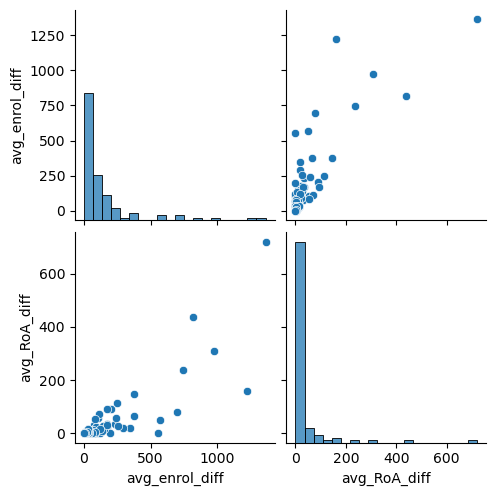

In [95]:
# check distribution
sns.pairplot(result_merge[['avg_enrol_diff', 'avg_RoA_diff']], dropna = True)

<Axes: xlabel='avg_enrol_diff', ylabel='Count'>

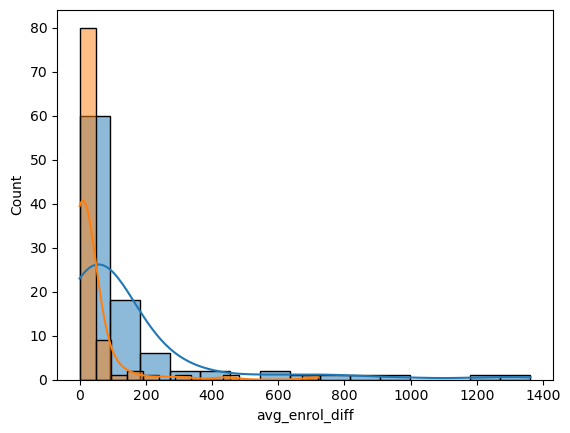

In [96]:
sns.histplot(x = 'avg_enrol_diff', data = result_merge, kde = True, bins = 15)
sns.histplot(x = 'avg_RoA_diff', data = result_merge, kde = True, bins = 15)

In [100]:
# label based on the threshold
result_merge['enrol_base'] = [ 1 if x <= median_enrol else 0 for x in result_merge['avg_enrol_diff']]
result_merge['RoA_base'] = [ 1 if x <= median_RoA else 0 for x in result_merge['avg_RoA_diff']]

In [101]:
result_merge.head()

,courseID,courseName,categoryName,prediction,avg_enrol_diff,avg_RoA_diff,enrol_base,RoA_base
0,106,Einführung in die KI,Über KI,no update,1226.166667,159.666667,0,0
1,58,AICE your exams – Generative KI als Copilot im...,Studieren,no update,1361.833333,721.000000,0,0
2,322,IBM-Grundlagen der Künstlichen Intelligenz,Über KI,no update,976.500000,309.333333,0,0
3,99,KI für Alle 1: Einführung in die Künstliche In...,Über KI,no update,567.833333,50.833333,0,0
4,313,EU AI Act Essentials,Studieren,no update,746.333333,237.666667,0,0


In [103]:
# export the prediction table
result_merge.to_excel('C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Predictive modelling/QA_Jun2026/pred_result.xlsx', index = False)